In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('customer_churn.csv')

In [7]:
print(customers.head())

  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB
None


In [10]:
#Data Cleaning
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Handle missing values
df.fillna(0, inplace=True)

In [11]:
#Aggregation
total_customers = df['CustomerID'].nunique()
avg_monthly = df['MonthlyCharges'].mean()
total_revenue = df['TotalCharges'].sum()
print("Total Customers:", total_customers)
print("Average Monthly Charges:", avg_monthly)
print("Total Revenue:", total_revenue)

Total Customers: 500
Average Monthly Charges: 113.636
Total Revenue: 2118941


In [12]:
#Churn Analysis (Aggregation)
churn_count = df['Churn'].value_counts()
print(churn_count)

Churn
0    447
1     53
Name: count, dtype: int64


In [13]:
#Group Analysis (Aggregation)
contract_analysis = df.groupby('Contract')['Churn'].mean()
print(contract_analysis)

Contract
Month-to-month    0.205882
One year          0.043011
Two year          0.069444
Name: Churn, dtype: float64


In [14]:
#Multiple Conditions Filtering
high_risk = df[(df['MonthlyCharges'] > 100) & (df['Churn'] == 1)]
print(high_risk.head())

   CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
11     C00012       7             110          7282  Month-to-month   
13     C00014       8             158          6194  Month-to-month   
18     C00019       7             156          5389        One year   
31     C00032      10             196          4825  Month-to-month   
54     C00055       9             157          7022  Month-to-month   

       PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
11  Electronic Check               No              1      1  
13       Credit Card               No              1      1  
18     Bank Transfer              Yes              0      1  
31       Credit Card              Yes              0      1  
54     Bank Transfer               No              0      1  


In [15]:
#Pivot Table
pivot = pd.pivot_table(
    df,
    values='MonthlyCharges',
    index='Contract',
    columns='Churn',
    aggfunc='mean'
)

print(pivot)

Churn                    0           1
Contract                              
Month-to-month  110.725926  120.942857
One year        112.769663  141.500000
Two year        111.335821  151.300000


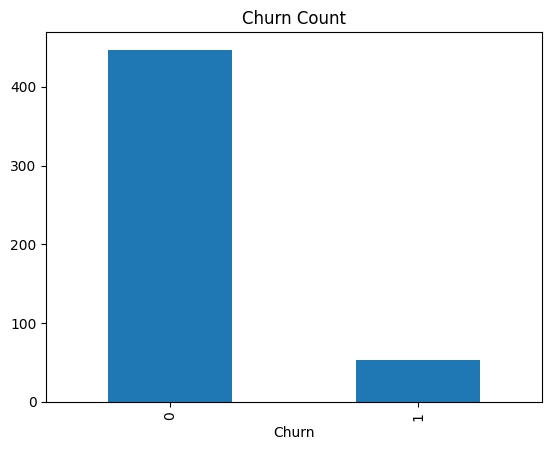

In [16]:
#Churn Distribution
df['Churn'].value_counts().plot(kind='bar', title='Churn Count')
plt.show()

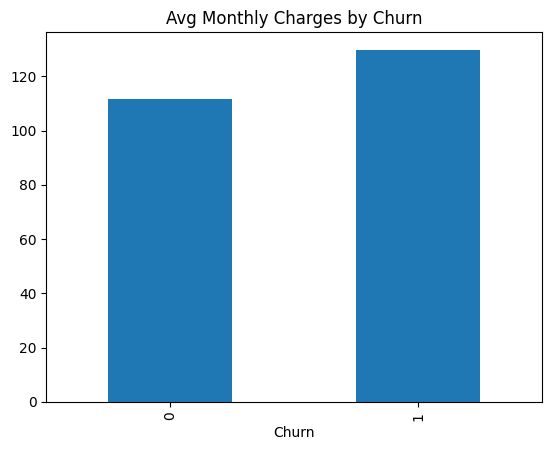

In [17]:
#Monthly Charges vs Churn
df.groupby('Churn')['MonthlyCharges'].mean().plot(kind='bar', title='Avg Monthly Charges by Churn')
plt.show()

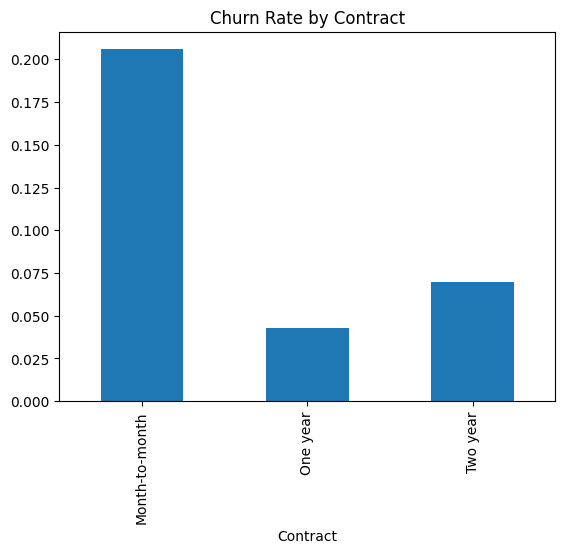

In [18]:
#Contract vs Churn
df.groupby('Contract')['Churn'].mean().plot(kind='bar', title='Churn Rate by Contract')
plt.show()

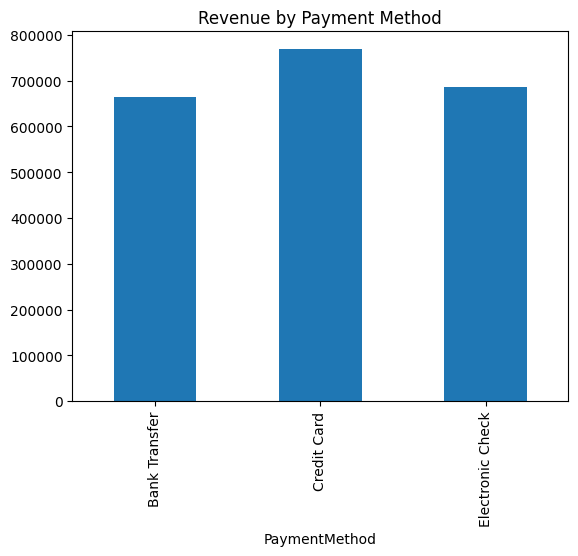

In [19]:
#Revenue by Payment Method
df.groupby('PaymentMethod')['TotalCharges'].sum().plot(kind='bar', title='Revenue by Payment Method')
plt.show()